
## D-1 PERCOBAAN HISTOGRAM
---


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

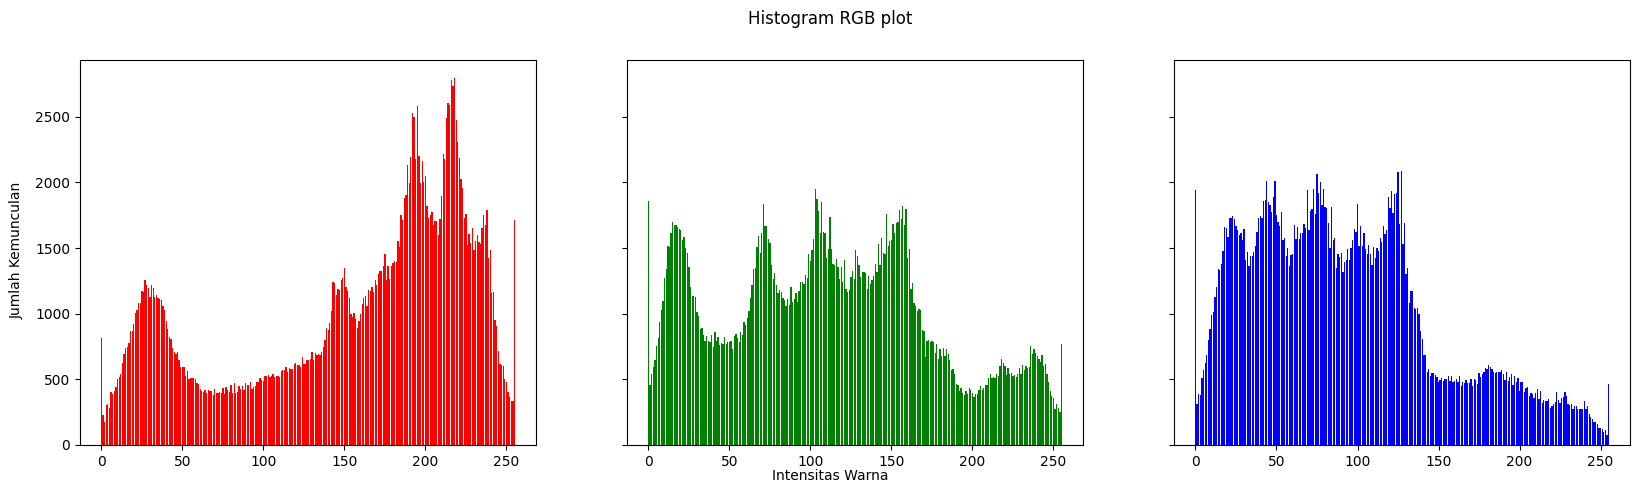

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

plt.show()

## PERTANYAAN PRAKTIKUM D1
---

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?
2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg. Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung gelap, terang, atau kontras rendah.

### Jawab Pertanyaan Praktikum D1

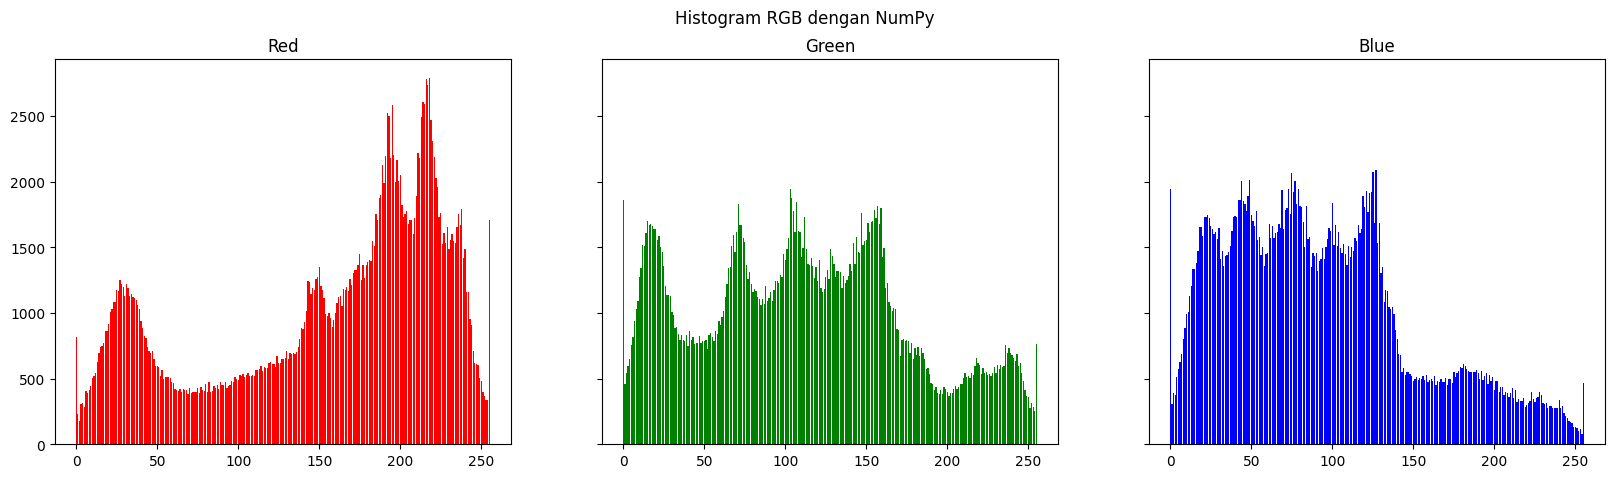

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB dengan NumPy")

axs[0].bar(np.arange(256), red_np, color='red')
axs[0].set_title("Red")
axs[1].bar(np.arange(256), green_np, color='green')
axs[1].set_title("Green")
axs[2].bar(np.arange(256), blue_np, color='blue')
axs[2].set_title("Blue")

plt.show()


Histogram manual dan NumPy identik karena keduanya menghitung distribusi piksel berdasarkan intensitas (0–255).

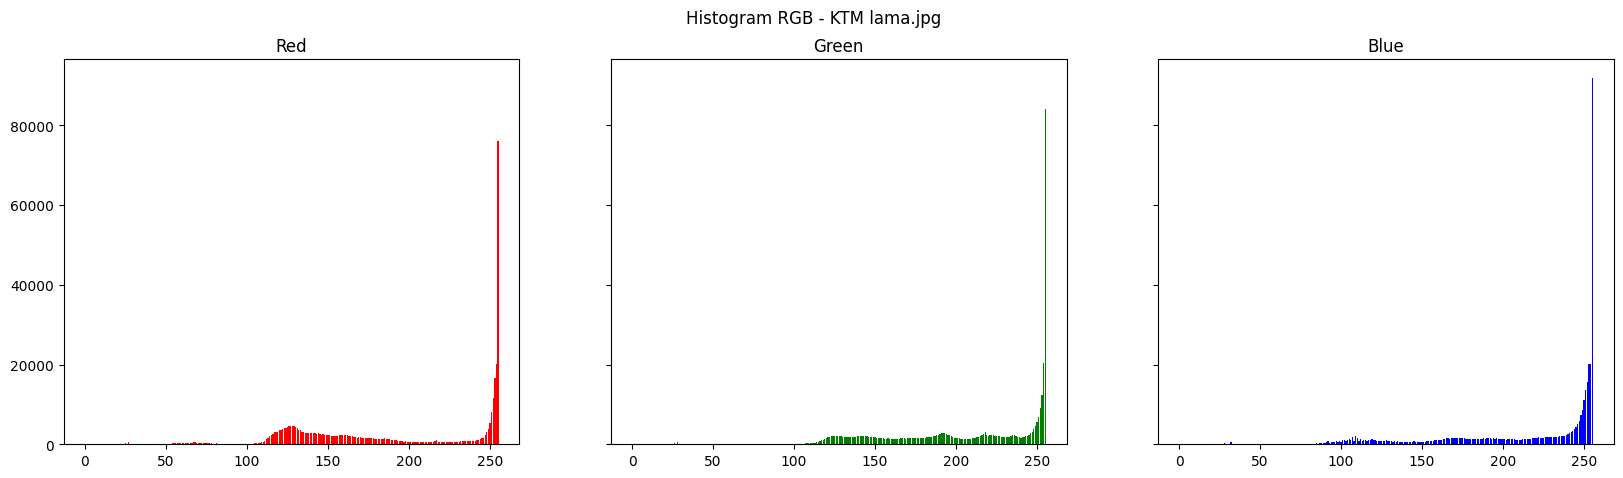

Rata-rata intensitas:
Red   : 189.37
Green : 207.78
Blue  : 216.25


In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB - KTM lama.jpg")

axs[0].bar(np.arange(256), red_np, color='red')
axs[0].set_title("Red")

axs[1].bar(np.arange(256), green_np, color='green')
axs[1].set_title("Green")

axs[2].bar(np.arange(256), blue_np, color='blue')
axs[2].set_title("Blue")

plt.show()

mean_red = np.mean(np.repeat(np.arange(256), red_np))
mean_green = np.mean(np.repeat(np.arange(256), green_np))
mean_blue = np.mean(np.repeat(np.arange(256), blue_np))

print("Rata-rata intensitas:")
print(f"Red   : {mean_red:.2f}")
print(f"Green : {mean_green:.2f}")
print(f"Blue  : {mean_blue:.2f}")

Analisis:
- Gambar tidak gelap karena nilai rata-rata intensitas lebih dari 128.
- Gambar cenderung terang, terutama karena channel Green dan Blue dominan di rentang tinggi.
- Ada sedikit sebaran di area gelap pada Red, tapi secara keseluruhan gambar memiliki kontras cukup baik (karena histogram tidak menumpuk di satu sisi saja).

## D-2 PERCOBAAN HISTOGRAM EQUALIZATION

Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

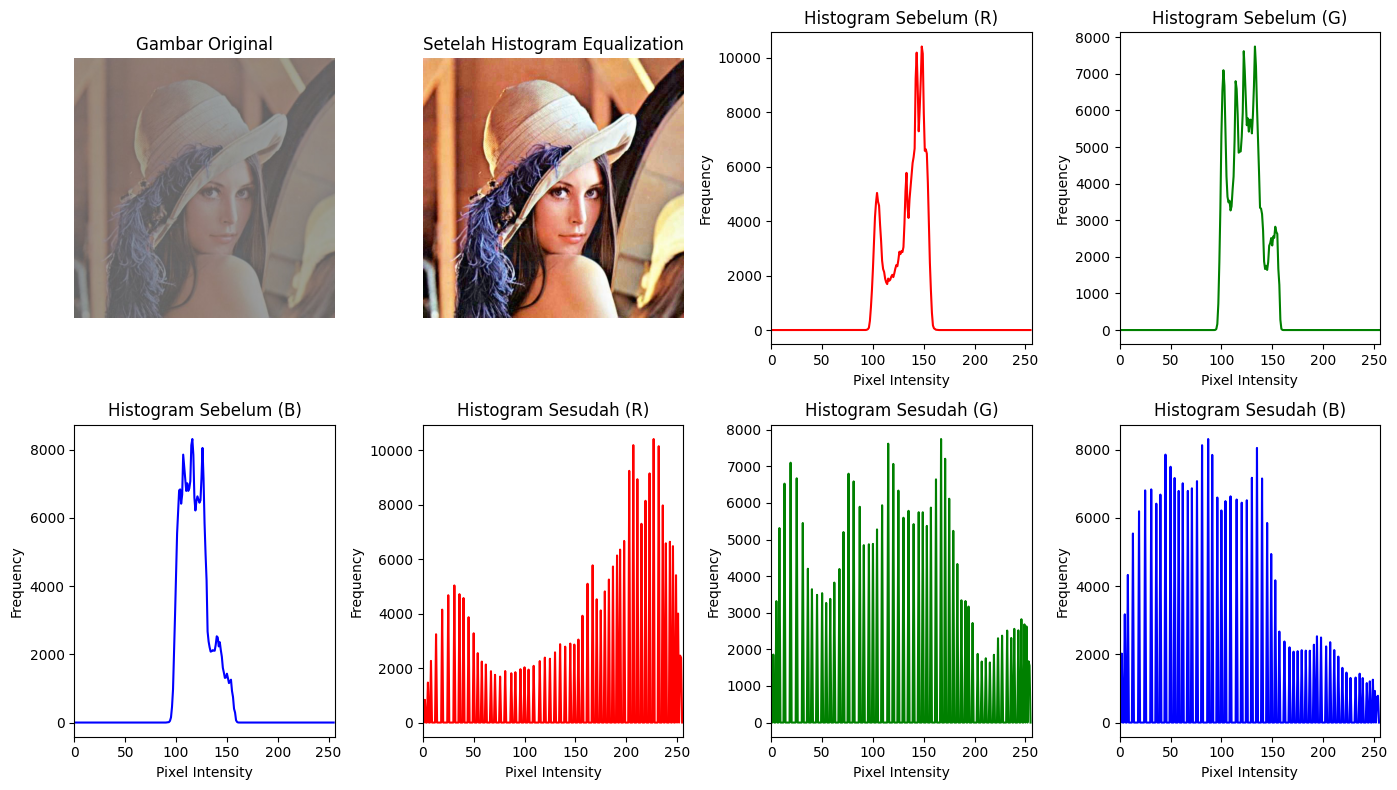

In [12]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

hist, bins = np.histogram(img.flatten(), 256, [0, 256])
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()

cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

img_equalized = cdf_final[img]

plt.figure(figsize=(14, 8))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_equalized)
plt.title('Setelah Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(2, 4, 3 + i)
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.title(f'Histogram Sebelum ({color.upper()})')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(2, 4, 6 + i)
    hist_eq = cv.calcHist([img_equalized], [i], None, [256], [0, 256])
    plt.plot(hist_eq, color=color)
    plt.title(f'Histogram Sesudah ({color.upper()})')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini.  

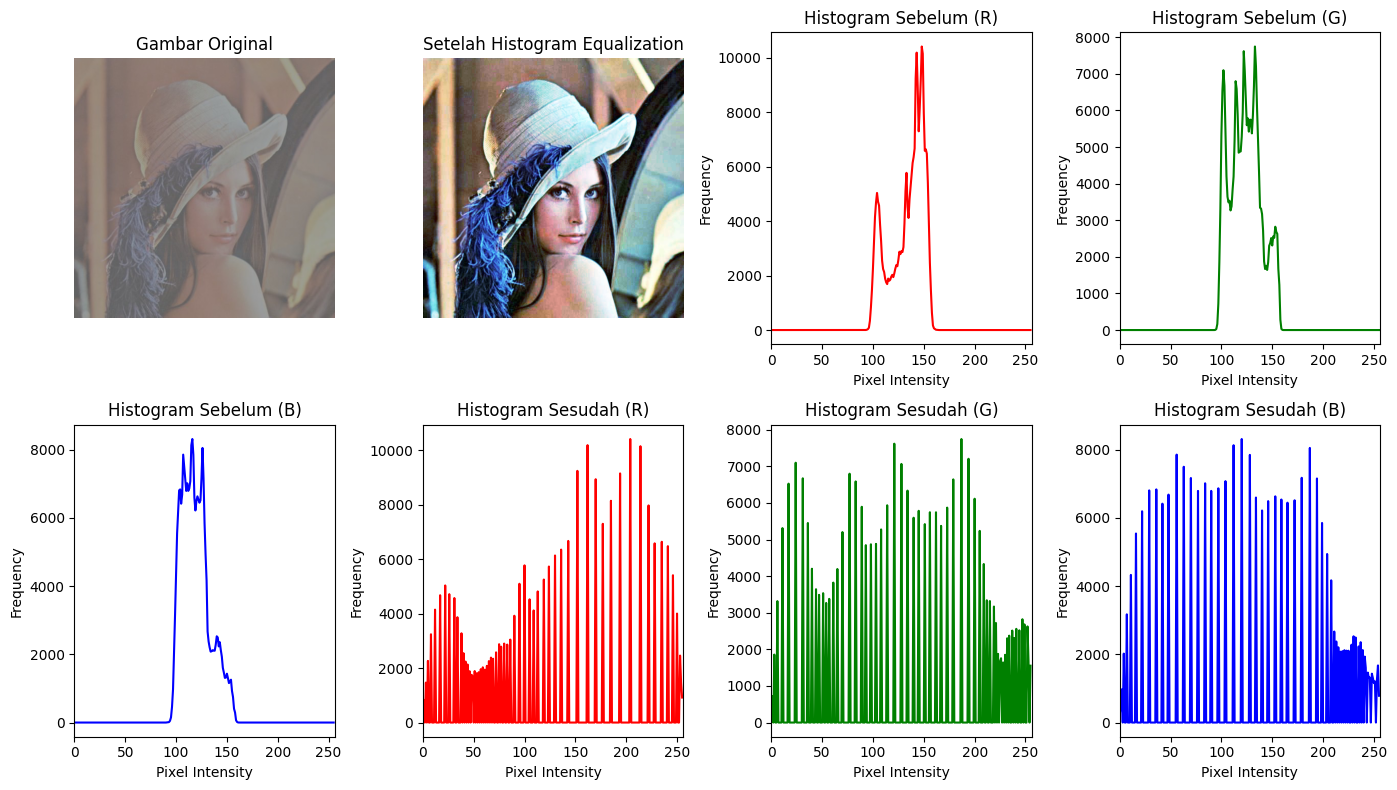

In [9]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_equalized = np.zeros_like(img)
for i in range(3):
    img_equalized[:, :, i] = cv.equalizeHist(img[:, :, i])

plt.figure(figsize=(14, 8))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(img_equalized)
plt.title('Setelah Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(2, 4, 3 + i)
    hist = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.title(f'Histogram Sebelum ({color.upper()})')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(2, 4, 6 + i)
    hist_eq = cv.calcHist([img_equalized], [i], None, [256], [0, 256])
    plt.plot(hist_eq, color=color)
    plt.title(f'Histogram Sesudah ({color.upper()})')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## PERTANYAAN PRAKTIKUM D2

1. Perbandingan Citra Lena
- Gunakan hasil histogram equalization pada citra lena.jpg.
- Hitung nilai PSNR antara citra asli dan citra hasil equalization.
- Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas visual citra? Apakah ada detail baru yang muncul setelah equalization?

2. Gunakan Citra KTM Lama.jpg
- Terapkan histogram equalization pada citra KTM lama.jpg.
- Tampilkan citra asli, citra hasil equalization, serta histogram keduanya dalam satu layout.
- Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization. Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

Jawab Pertanyaan Praktikum D2

PSNR: 17.948401486845306 dB


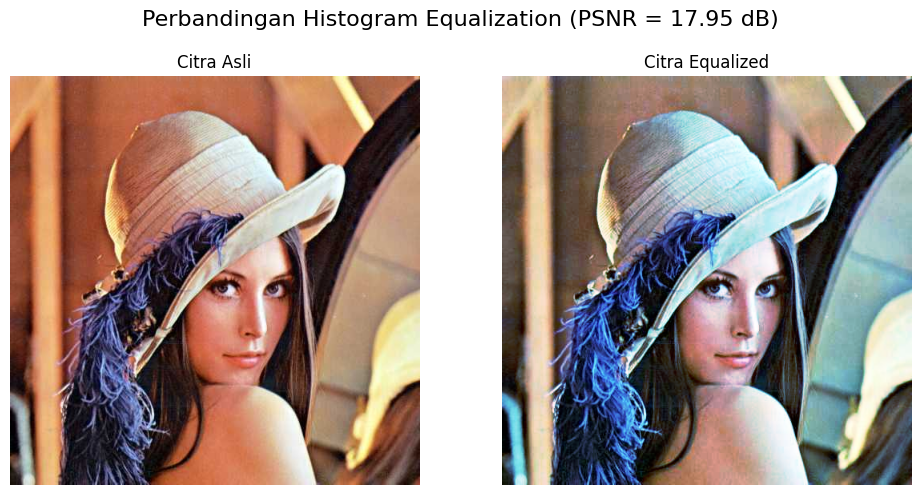

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_equalized = np.zeros_like(img)
for i in range(3):
    img_equalized[:, :, i] = cv.equalizeHist(img[:, :, i])

mse = np.mean((img.astype(np.float64) - img_equalized.astype(np.float64)) ** 2)
psnr = float('inf') if mse == 0 else 10 * np.log10((255 ** 2) / mse)
print("PSNR:", psnr, "dB")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f"Perbandingan Histogram Equalization (PSNR = {psnr:.2f} dB)", fontsize=16)

axs[0].imshow(img)
axs[0].set_title("Citra Asli")
axs[0].axis("off")

axs[1].imshow(img_equalized)
axs[1].set_title("Citra Equalized")
axs[1].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Histogram equalization pada citra Lena menghasilkan citra dengan kontras lebih tinggi. Nilai PSNR sebesar 17.95 dB tergolong rendah, yang menunjukkan perbedaan cukup besar dibanding citra asli secara kuantitatif. Namun, secara visual hasilnya justru memperlihatkan detail tambahan pada objek karena peningkatan kontras.

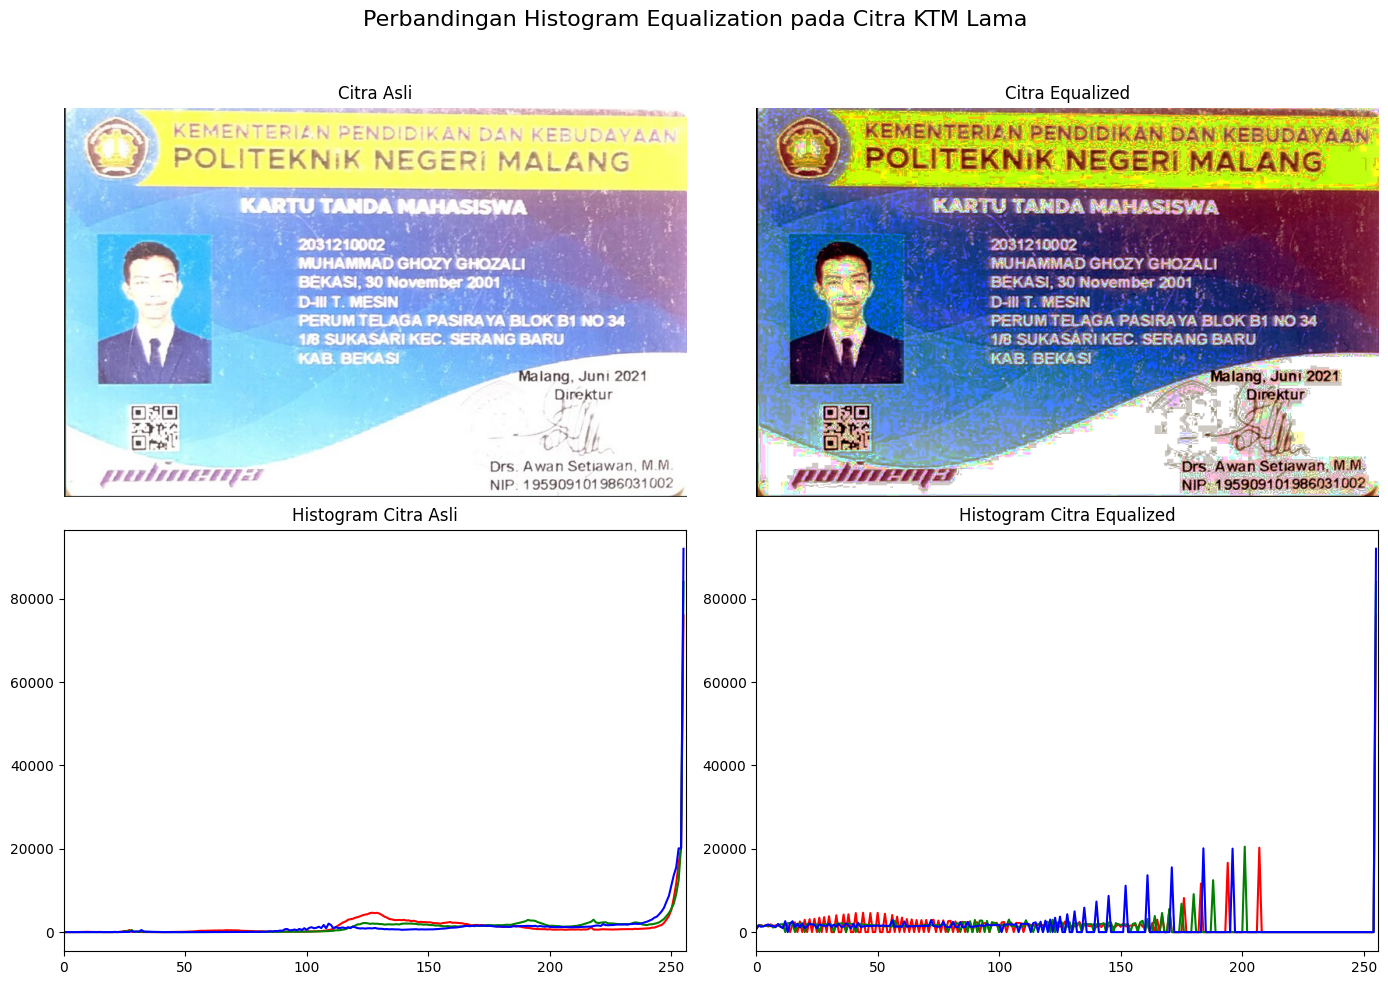

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load citra
img = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Equalization per channel
img_equalized = np.zeros_like(img)
for i in range(3):
    img_equalized[:, :, i] = cv.equalizeHist(img[:, :, i])

# Hitung histogram citra asli dan equalized
colors = ('r', 'g', 'b')
hist_orig = []
hist_eq = []
for i, col in enumerate(colors):
    hist_orig.append(cv.calcHist([img], [i], None, [256], [0, 256]))
    hist_eq.append(cv.calcHist([img_equalized], [i], None, [256], [0, 256]))

# Plot layout
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Perbandingan Histogram Equalization pada Citra KTM Lama", fontsize=16)

# Citra asli
axs[0, 0].imshow(img)
axs[0, 0].set_title("Citra Asli")
axs[0, 0].axis("off")

# Citra hasil equalization
axs[0, 1].imshow(img_equalized)
axs[0, 1].set_title("Citra Equalized")
axs[0, 1].axis("off")

# Histogram citra asli
for i, col in enumerate(colors):
    axs[1, 0].plot(hist_orig[i], color=col)
axs[1, 0].set_title("Histogram Citra Asli")
axs[1, 0].set_xlim([0, 256])

# Histogram citra equalized
for i, col in enumerate(colors):
    axs[1, 1].plot(hist_eq[i], color=col)
axs[1, 1].set_title("Histogram Citra Equalized")
axs[1, 1].set_xlim([0, 256])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

1. Citra Asli (KTM Lama - kiri atas)
Warna terlihat agak kusam, dominan biru dan kuning, dengan kontras rendah.
Bagian wajah pada foto agak redup, detail pada area gelap/terang kurang jelas.
Teks masih terbaca, tetapi kontras dengan latar belakang tidak terlalu tinggi, sehingga keterbacaan bisa kurang maksimal.
Dari histogram (kiri bawah), terlihat bahwa distribusi intensitas menumpuk di area terang (sekitar 240-255), menandakan citra cenderung overexposed (terlalu terang).

2. Citra Hasil Histogram Equalization (kanan atas)
Kontras meningkat cukup drastis.
Wajah pada foto terlihat jauh lebih tegas, begitu juga garis tepi teks.
Namun, warna menjadi lebih mencolok, bahkan agak “keras” (terlalu kontras) sehingga beberapa area kehilangan gradasi halus.
Misalnya, bagian background biru terlihat pecah menjadi blok-blok warna dengan transisi kasar.
Dari histogram (kanan bawah), distribusi intensitas lebih merata di seluruh rentang [0–255].
Ini sesuai dengan tujuan histogram equalization: menyebarkan intensitas agar tidak hanya menumpuk di area terang.

3. Perbandingan Visual
Detail wajah → lebih jelas setelah equalization.
Teks → lebih kontras dengan latar belakang, sehingga lebih mudah dibaca.
Latar belakang → kontras tinggi membuat tekstur latar lebih menonjol, tetapi kadang malah membuat hasil terlihat kasar dan kurang natural.

4. Kualitas Informasi
Meningkat: Equalization membantu mempertegas detail, khususnya untuk teks dan foto wajah, sehingga informasi lebih jelas.Namun: Perubahan warna dan kontras berlebihan membuat hasil terlihat tidak natural. Untuk dokumen identitas seperti KTM, ini bisa mengurangi kenyamanan visual karena terlalu “keras”.

Kesimpulan:
Histogram equalization pada citra KTM Lama berhasil meningkatkan keterbacaan dan detail informasi (teks dan wajah lebih jelas), tetapi efek sampingnya adalah kontras berlebihan sehingga warna tampak kasar. Untuk aplikasi pemrosesan citra dokumen, metode ini bermanfaat untuk memperjelas informasi, tetapi sebaiknya dipadukan dengan teknik lain (misalnya CLAHE - Contrast Limited Adaptive Histogram Equalization) agar hasil lebih natural dan tidak terlalu keras.

## D-3 TUGAS PRAKTIKUM DITHERING
---

Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman modul ini! (Gunakan gambar lena.jpg)

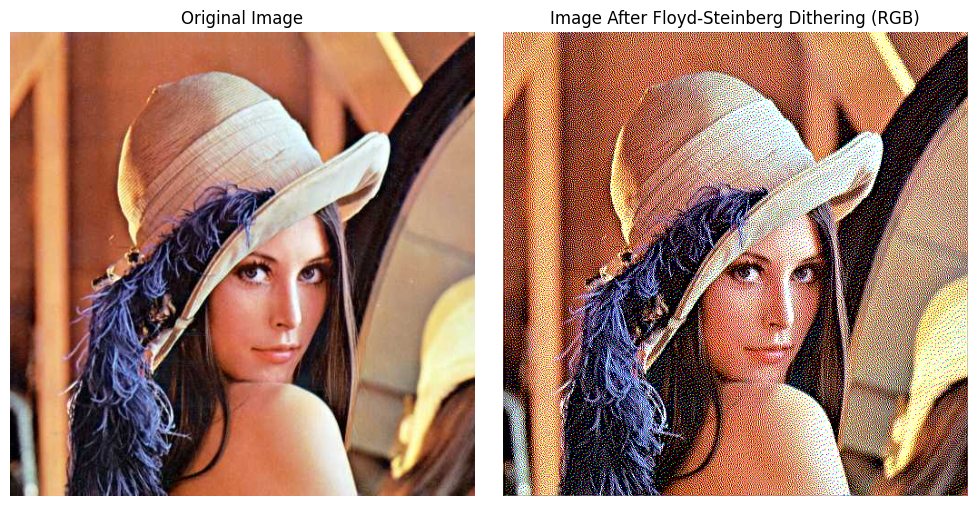

In [13]:
fs_matrix = np.array([[0, 0, 7],
                      [3, 5, 1]]) / 16

img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img = img.astype(np.float32) / 255.0

rows, cols, channels = img.shape

dithered_img = np.copy(img)

for y in range(rows - 1):
    for x in range(1, cols - 1):
        for c in range(channels):
            old_pixel = dithered_img[y, x, c]
            new_pixel = np.round(old_pixel)
            dithered_img[y, x, c] = new_pixel
            error = old_pixel - new_pixel

            dithered_img[y, x+1, c] += error * 7 / 16
            dithered_img[y+1, x-1, c] += error * 3 / 16
            dithered_img[y+1, x, c]   += error * 5 / 16
            dithered_img[y+1, x+1, c] += error * 1 / 16

dithered_img = (dithered_img * 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dithered_img)
plt.title('Image After Floyd-Steinberg Dithering (RGB)')
plt.axis('off')

plt.tight_layout()
plt.show()

Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga menampilkan gambar di bawah ini!

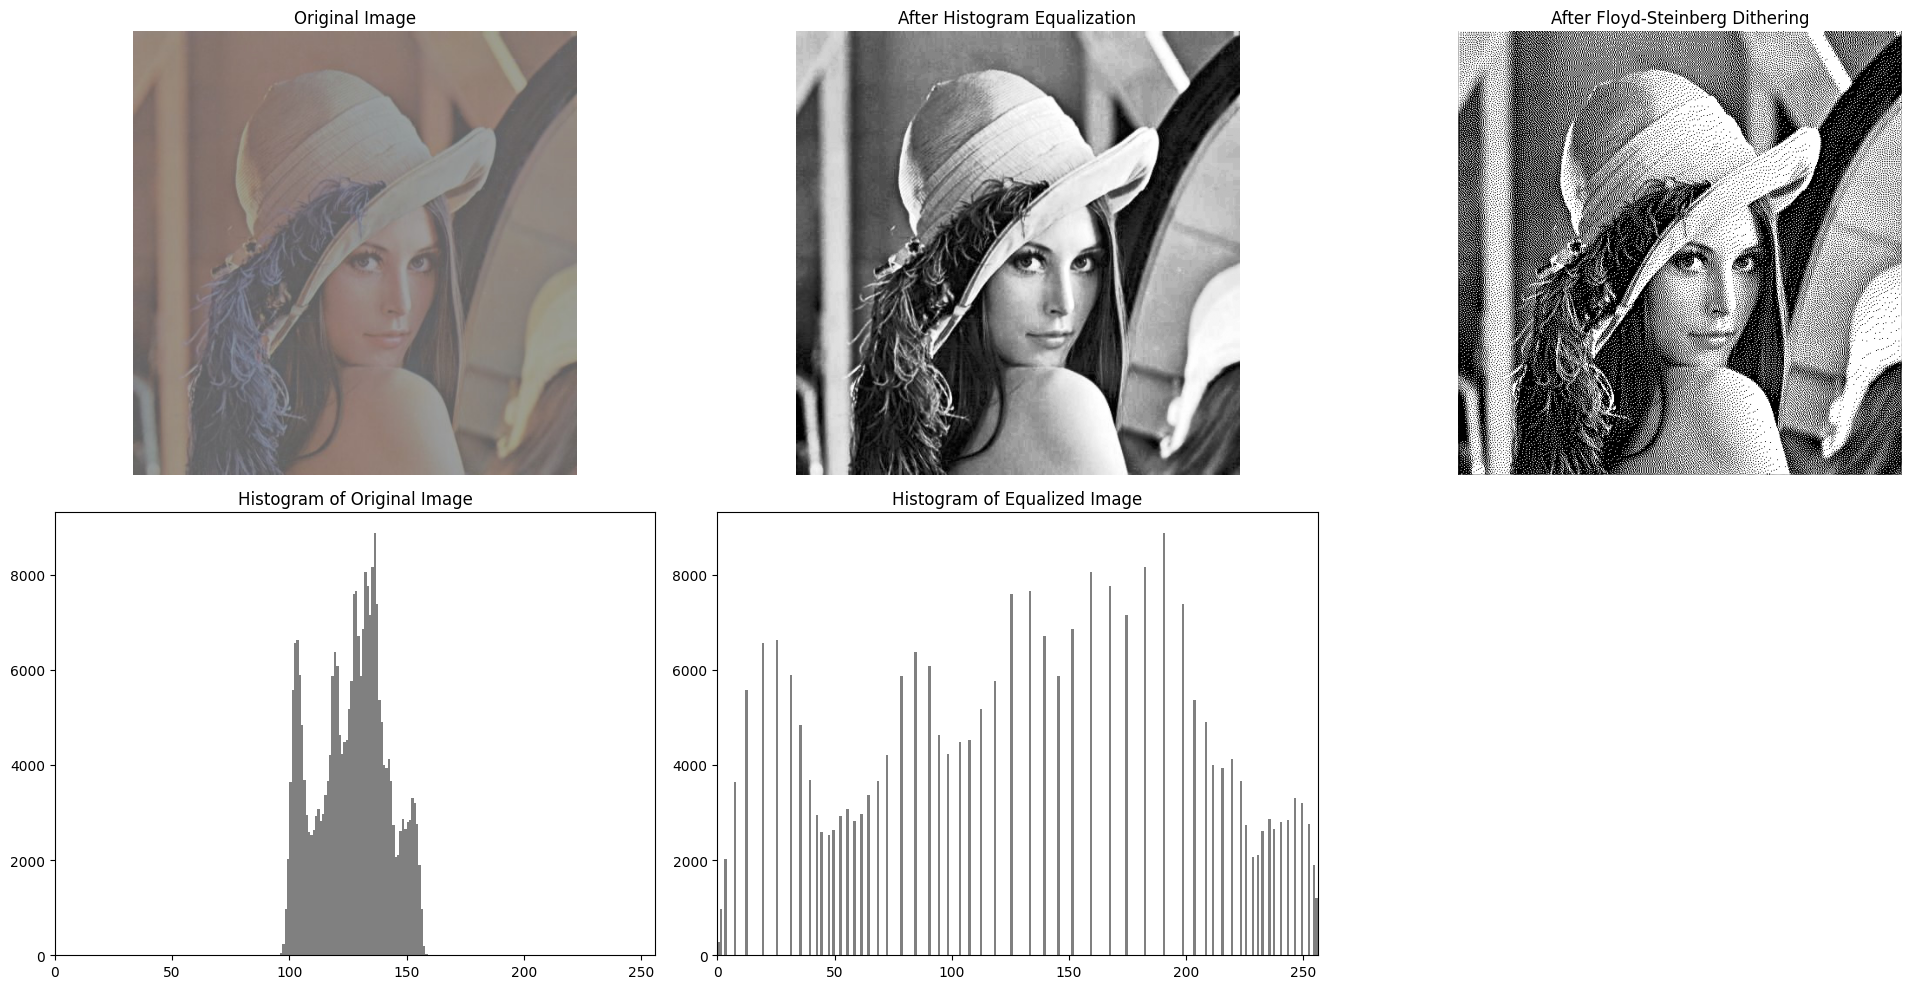

In [11]:
img_path = '/content/drive/MyDrive/PCVK/Images/lena_lc.jpg'
img = cv.imread(img_path)
img_ori = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

equalized_img = cv.equalizeHist(gray_img)

fs_matrix = np.array([[0, 0, 7],
                      [3, 5, 1]]) / 16

img_normalized = equalized_img.astype(np.float32) / 255.0

rows, cols = img_normalized.shape

dithered_img = np.copy(img_normalized)

for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered_img[y, x]
        new_pixel = np.round(old_pixel)
        dithered_img[y, x] = new_pixel
        error = old_pixel - new_pixel

        dithered_img[y, x + 1] += error * 7 / 16
        dithered_img[y + 1, x - 1] += error * 3 / 16
        dithered_img[y + 1, x] += error * 5 / 16
        dithered_img[y + 1, x + 1] += error * 1 / 16

dithered_img = (dithered_img * 255).astype(np.uint8)

plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_ori)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(gray_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Original Image')
plt.xlim([0, 256])

plt.subplot(2, 3, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('After Histogram Equalization')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.hist(equalized_img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram of Equalized Image')
plt.xlim([0, 256])

plt.subplot(2, 3, 3)
plt.imshow(dithered_img, cmap='gray')
plt.title('After Floyd-Steinberg Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()